# Campus Placement EDA for BTech Students

**Who this is for:** 2nd-year BTech **AIML** students (for example at SRM) who are starting data analysis with Python.

**Question we will study:**

> What is associated with getting a campus placement, and how did that look over the last five graduating years (2021–2025)?

**Why this problem?**
You already know CGPA, internships, backlogs, and placement talks. EDA is how we check those stories with a table and a few charts — before anyone builds a machine-learning model.

**How to use this notebook**
1. Run the cells **in order** (Stage 1 → Stage 7) using `Shift+Enter`.
2. Read the short note above each code cell.
3. Try the extra questions at the end.

The CSV is already in this project: `data/campus_placement_btech.csv`.  
It is a **teaching dataset** (synthetic). It is not official SRM / company data, but the patterns are realistic enough to learn from.

A full written explanation of every stage is in `docs/NOTEBOOK_GUIDE.md`.


---
# Stage 1 — Import Python libraries

We only need four libraries:

| Library | Role |
| --- | --- |
| **pandas** | Load the CSV and work with tables |
| **numpy** | Simple numeric helpers (for example filling missing numbers) |
| **matplotlib** | Draw graphs |
| **seaborn** | Slightly nicer statistical graphs |

If this cell gives `ModuleNotFoundError`, run `pip install -r requirements.txt` in a terminal and restart the kernel.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

print("Libraries imported successfully.")
print("pandas version:", pd.__version__)
print("seaborn version:", sns.__version__)


Libraries imported successfully.
pandas version: 3.0.5
seaborn version: 0.13.2


---
# Stage 2 — Import data and examine the dataset

First we **load** the file, then we **look** at it. We do not clean or plot yet.

Good habit: never trust a CSV until you have seen its size, column names, a few rows, missing values, and odd category labels.


In [2]:
# Works whether you opened Jupyter from the notebooks/ folder or the project root
candidates = [
    Path("../data/campus_placement_btech.csv"),
    Path("data/campus_placement_btech.csv"),
]
data_path = next(path for path in candidates if path.exists())
print("Reading:", data_path.resolve())

df = pd.read_csv(data_path)
print("Done. The table is stored in a variable called df.")


Reading: /workspace/data/campus_placement_btech.csv
Done. The table is stored in a variable called df.


### 2.1 Size, first rows, last rows

- `shape` → (number of rows, number of columns)
- `head()` → first 5 students
- `tail()` → last 5 students


In [3]:
print("Rows, columns:", df.shape)
print()
print("Column names:")
print(list(df.columns))
print()
print("First 5 rows:")
df.head()


Rows, columns: (1508, 16)

Column names:
['student_id', 'graduation_year', 'college_type', 'branch', 'gender', 'cgpa', 'internships', 'projects', 'backlogs', 'coding_skill', 'communication_skill', 'knows_python', 'placement_status', 'company_type', 'package_lpa', 'job_role']

First 5 rows:


,student_id,graduation_year,college_type,branch,gender,cgpa,internships,projects,backlogs,coding_skill,communication_skill,knows_python,placement_status,company_type,package_lpa,job_role
0,BT20210001,2021,State University,IT,Female,5.30,3.0,4,0,Beginner,Good,Yes,Not Placed,NaN,NaN,NaN
1,BT20240002,2024,NIT,ECE,Male,8.31,2.0,1,0,Intermediate,Good,No,Placed,Service,7.61,Software Developer
2,BT20240003,2024,Private Engineering College,AIML,Male,7.67,2.0,2,0,Beginner,Good,Yes,Placed,Service,8.24,Data Analyst
3,BT20230004,2023,Private Engineering College,CSE,Male,5.55,2.0,2,0,Beginner,Average,No,Placed,Product,13.61,Software Developer
4,BT20210005,2021,Private Engineering College,MECH,Male,7.58,0.0,0,0,Intermediate,Average,Yes,Not Placed,NaN,NaN,NaN


In [4]:
print("Last 5 rows:")
df.tail()


Last 5 rows:


,student_id,graduation_year,college_type,branch,gender,cgpa,internships,projects,backlogs,coding_skill,communication_skill,knows_python,placement_status,company_type,package_lpa,job_role
1503,BT20250639,2025,Private Engineering College,CIVIL,Male,7.35,2.0,3,0,Beginner,Average,Yes,Placed,Core,6.67,Core Engineer
1504,BT20210472,2021,Private Engineering College,MECH,Male,6.60,0.0,5,0,Intermediate,Average,No,Not Placed,NaN,NaN,NaN
1505,BT20211150,2021,Private Engineering College,EEE,Male,7.62,1.0,3,0,Advanced,Average,Yes,Placed,Service,3.68,Embedded Engineer
1506,BT20210393,2021,NIT,EEE,Male,5.09,1.0,5,0,Beginner,Average,No,Not Placed,NaN,NaN,NaN
1507,BT20211159,2021,Deemed University,CSE,Male,6.45,2.0,1,2,Beginner,Good,Yes,Placed,Service,7.56,Data Analyst


### 2.2 Column types and missing-value counts

`info()` tells you whether a column is text (`object`) or a number (`int64` / `float64`), and how many values are non-null.


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1508 entries, 0 to 1507
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           1508 non-null   str    
 1   graduation_year      1508 non-null   int64  
 2   college_type         1508 non-null   str    
 3   branch               1508 non-null   str    
 4   gender               1508 non-null   str    
 5   cgpa                 1508 non-null   float64
 6   internships          1453 non-null   float64
 7   projects             1508 non-null   int64  
 8   backlogs             1508 non-null   int64  
 9   coding_skill         1483 non-null   str    
 10  communication_skill  1468 non-null   str    
 11  knows_python         1508 non-null   str    
 12  placement_status     1508 non-null   str    
 13  company_type         1182 non-null   str    
 14  package_lpa          1182 non-null   float64
 15  job_role             1182 non-null   str    
dtyp

### 2.3 Numeric summary

`describe()` gives count, mean, min, max, and quartiles for numeric columns. This is a quick way to spot impossible values (for example a CGPA of 11).


In [6]:
df.describe()


,graduation_year,cgpa,internships,projects,backlogs,package_lpa
count,1508.000000,1508.000000,1453.000000,1508.000000,1508.000000,1182.000000
mean,2022.914456,7.141830,1.062629,2.483422,0.350133,7.571218
std,1.421693,0.943729,1.012083,1.577586,0.638891,3.254781
min,2021.000000,5.000000,0.000000,0.000000,-1.000000,2.400000
25%,2022.000000,6.520000,0.000000,1.000000,0.000000,5.300000
50%,2023.000000,7.120000,1.000000,2.000000,0.000000,6.870000
75%,2024.000000,7.750000,2.000000,3.000000,1.000000,9.170000
max,2025.000000,10.400000,4.000000,8.000000,4.000000,27.860000


### 2.4 Look at category labels (this is where mess hides)

In a clean file, `branch` should have 7 labels and `placement_status` should have 2. Let us check the raw file.


In [7]:
print("placement_status labels:")
print(df["placement_status"].value_counts(dropna=False))
print()
print("branch labels:")
print(df["branch"].value_counts(dropna=False))
print()
print("coding_skill labels:")
print(df["coding_skill"].value_counts(dropna=False))


placement_status labels:
placement_status
Placed        1164
Not Placed     306
placed          18
not placed      12
NotPlaced        8
Name: count, dtype: int64

branch labels:
branch
CSE       344
AIML      233
ECE       230
MECH      200
IT        166
EEE       154
CIVIL     146
aiml        9
CSE         7
cse         4
IT          3
ECE         3
AIML        2
MECH        2
civil       1
CIVIL       1
eee         1
CSE         1
mech        1
Name: count, dtype: int64

coding_skill labels:
coding_skill
Intermediate    701
Beginner        444
Advanced        338
NaN              25
Name: count, dtype: int64


### 2.5 Missing values and duplicate rows

- Missing values: cells pandas could not read as a real value (`NaN`).
- Duplicates: the same row twice (a data-entry accident).


In [8]:
print("Missing values in each column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Unique student_id values:", df["student_id"].nunique())


Missing values in each column:
student_id               0
graduation_year          0
college_type             0
branch                   0
gender                   0
cgpa                     0
internships             55
projects                 0
backlogs                 0
coding_skill            25
communication_skill     40
knows_python             0
placement_status         0
company_type           326
package_lpa            326
job_role               326
dtype: int64

Duplicate rows: 8
Unique student_id values: 1500


**What Stage 2 should have shown you**

1. About **1,508 rows** and **16 columns** (a few extra rows are duplicates).
2. `placement_status` is inconsistent: `Placed`, `placed`, `Not Placed`, `not placed`, `NotPlaced`.
3. `branch` has extra spaces and mixed case (`CSE  `, `aiml`).
4. Some internships / skills are missing.
5. `company_type` and `job_role` look missing for many students. In the CSV those cells were written as `NA` (not placed). pandas treats the text `NA` as missing by default. We will label them properly in Stage 3.

If you skip cleaning, a chart would treat `CSE` and `cse` as two different branches. That would be wrong.


---
# Stage 3 — Clean the data

We create `df_clean` so the original `df` is still there if we need it.

Cleaning plan (keep it simple):

1. Standardise `branch` and `placement_status` text.
2. Remove duplicate rows.
3. Fix impossible numbers (CGPA outside 0–10, negative backlogs).
4. Fill remaining missing values with a median (numbers) or the most common label (categories).
5. Add helper columns for charts.


In [9]:
df_clean = df.copy()

# 1a. Branch: remove spaces and make uppercase so 'cse', 'CSE ', 'CSE' become 'CSE'
df_clean["branch"] = df_clean["branch"].astype(str).str.strip().str.upper()

# 1b. Placement status: one spelling only
status = df_clean["placement_status"].astype(str).str.strip().str.lower()
status = status.replace({"notplaced": "not placed"})
df_clean["placement_status"] = status.map({"placed": "Placed", "not placed": "Not Placed"})

print("Clean branch labels:")
print(sorted(df_clean["branch"].unique()))
print()
print("Clean placement labels:")
print(df_clean["placement_status"].value_counts())


Clean branch labels:
['AIML', 'CIVIL', 'CSE', 'ECE', 'EEE', 'IT', 'MECH']

Clean placement labels:
placement_status
Placed        1182
Not Placed     326
Name: count, dtype: int64


In [10]:
# 2. Duplicate rows
print("Duplicates before:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Duplicates after:", df_clean.duplicated().sum())
print("Rows now:", df_clean.shape[0])


Duplicates before: 8
Duplicates after: 0
Rows now: 1500


In [11]:
# 3. Impossible numbers
print("CGPA min / max before fix:", df_clean["cgpa"].min(), "/", df_clean["cgpa"].max())
print("Backlogs with negative values:", (df_clean["backlogs"] < 0).sum())

# CGPA must be between 0 and 10. Impossible values → missing, then fill with median
bad_cgpa = (df_clean["cgpa"] < 0) | (df_clean["cgpa"] > 10)
df_clean.loc[bad_cgpa, "cgpa"] = np.nan
df_clean["cgpa"] = df_clean["cgpa"].fillna(df_clean["cgpa"].median())

# Backlogs cannot be negative
df_clean.loc[df_clean["backlogs"] < 0, "backlogs"] = 0

print("CGPA min / max after fix:", df_clean["cgpa"].min(), "/", df_clean["cgpa"].max())


CGPA min / max before fix: 5.0 / 10.4
Backlogs with negative values: 5
CGPA min / max after fix: 5.0 / 9.8


In [12]:
# 4. Fill remaining missing values
intern_median = df_clean["internships"].median()
coding_mode = df_clean["coding_skill"].mode()[0]
comm_mode = df_clean["communication_skill"].mode()[0]

print("Filling internships with median:", intern_median)
print("Filling coding_skill with mode:", coding_mode)
print("Filling communication_skill with mode:", comm_mode)

df_clean["internships"] = df_clean["internships"].fillna(intern_median).astype(int)
df_clean["coding_skill"] = df_clean["coding_skill"].fillna(coding_mode)
df_clean["communication_skill"] = df_clean["communication_skill"].fillna(comm_mode)

# Unplaced students: company and role are not applicable
unplaced = df_clean["placement_status"] == "Not Placed"
df_clean.loc[unplaced, "company_type"] = df_clean.loc[unplaced, "company_type"].fillna("Not Applicable")
df_clean.loc[unplaced, "job_role"] = df_clean.loc[unplaced, "job_role"].fillna("Not Applicable")


Filling internships with median: 1.0
Filling coding_skill with mode: Intermediate
Filling communication_skill with mode: Average


In [13]:
# 5. Helper columns (make later charts easier)
df_clean["is_placed"] = (df_clean["placement_status"] == "Placed").astype(int)

df_clean["cgpa_band"] = pd.cut(
    df_clean["cgpa"],
    bins=[0, 6, 7, 8, 10],
    labels=["Below 6", "6–7", "7–8", "8+"],
    include_lowest=True,
)

print("Missing values left in df_clean:")
print(df_clean.isna().sum())
print()
print("Placement rate (share of students placed):", round(df_clean["is_placed"].mean() * 100, 1), "%")
df_clean.head()


Missing values left in df_clean:
student_id               0
graduation_year          0
college_type             0
branch                   0
gender                   0
cgpa                     0
internships              0
projects                 0
backlogs                 0
coding_skill             0
communication_skill      0
knows_python             0
placement_status         0
company_type             0
package_lpa            324
job_role                 0
is_placed                0
cgpa_band                0
dtype: int64

Placement rate (share of students placed): 78.4 %


,student_id,graduation_year,college_type,branch,gender,cgpa,internships,projects,backlogs,coding_skill,communication_skill,knows_python,placement_status,company_type,package_lpa,job_role,is_placed,cgpa_band
0,BT20210001,2021,State University,IT,Female,5.30,3,4,0,Beginner,Good,Yes,Not Placed,Not Applicable,NaN,Not Applicable,0,Below 6
1,BT20240002,2024,NIT,ECE,Male,8.31,2,1,0,Intermediate,Good,No,Placed,Service,7.61,Software Developer,1,8+
2,BT20240003,2024,Private Engineering College,AIML,Male,7.67,2,2,0,Beginner,Good,Yes,Placed,Service,8.24,Data Analyst,1,7–8
3,BT20230004,2023,Private Engineering College,CSE,Male,5.55,2,2,0,Beginner,Average,No,Placed,Product,13.61,Software Developer,1,Below 6
4,BT20210005,2021,Private Engineering College,MECH,Male,7.58,0,0,0,Intermediate,Average,Yes,Not Placed,Not Applicable,NaN,Not Applicable,0,7–8


`df_clean` is the table we will use from here. If a later chart looks strange, scroll back — the usual cause is running Stage 4 without running Stage 3.


---
# Stage 4 — Univariate analysis (one column at a time)

Look at each important field **alone** before relating it to placement. This answers: *How many? What is typical? Are there extremes?*


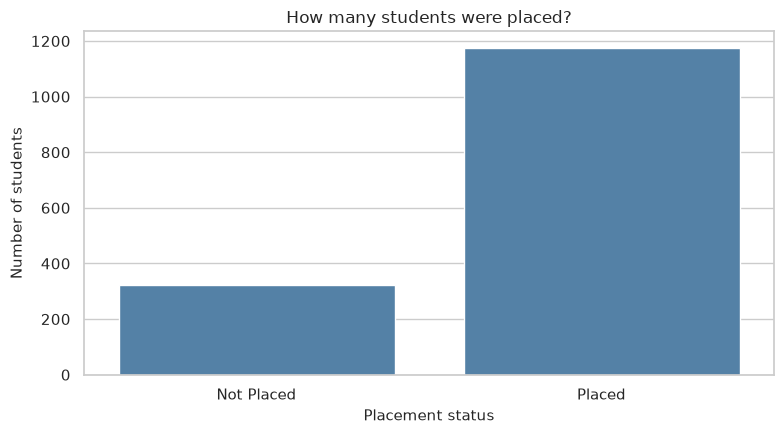

Placed: 1176 out of 1500  (78.4%)


In [14]:
# Overall placement count
ax = sns.countplot(data=df_clean, x="placement_status", color="steelblue")
ax.set_title("How many students were placed?")
ax.set_xlabel("Placement status")
ax.set_ylabel("Number of students")
plt.tight_layout()
plt.show()

n = len(df_clean)
n_placed = df_clean["is_placed"].sum()
print(f"Placed: {n_placed} out of {n}  ({n_placed / n * 100:.1f}%)")


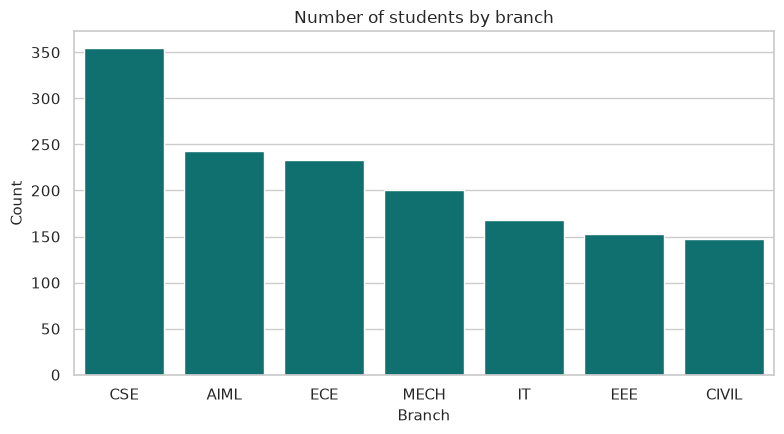

In [15]:
# Students in each branch
order = df_clean["branch"].value_counts().index
ax = sns.countplot(data=df_clean, x="branch", order=order, color="teal")
ax.set_title("Number of students by branch")
ax.set_xlabel("Branch")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


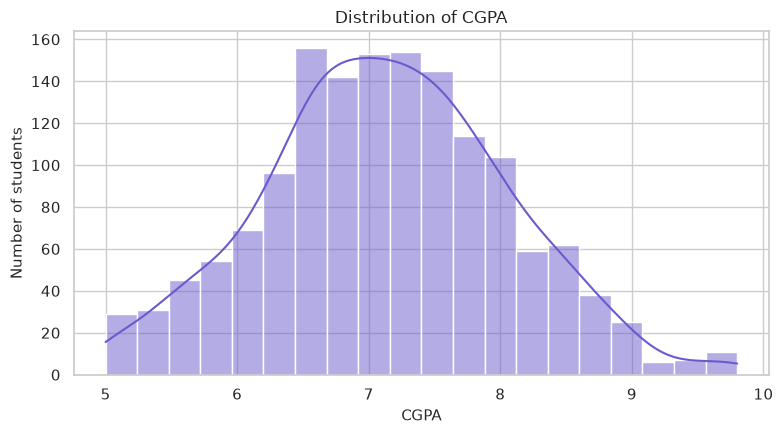

Typical CGPA (median): 7.12
Average CGPA (mean):   7.13


In [16]:
# CGPA spread
ax = sns.histplot(data=df_clean, x="cgpa", bins=20, color="slateblue", kde=True)
ax.set_title("Distribution of CGPA")
ax.set_xlabel("CGPA")
ax.set_ylabel("Number of students")
plt.tight_layout()
plt.show()

print("Typical CGPA (median):", df_clean["cgpa"].median())
print("Average CGPA (mean):  ", round(df_clean["cgpa"].mean(), 2))


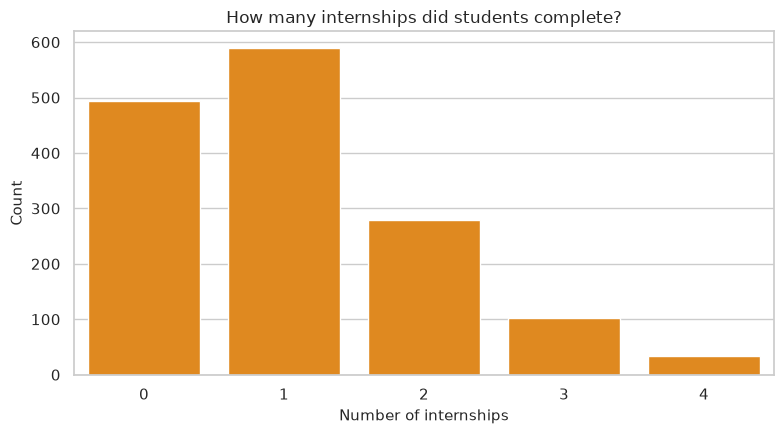

In [17]:
# Internships
ax = sns.countplot(data=df_clean, x="internships", color="darkorange")
ax.set_title("How many internships did students complete?")
ax.set_xlabel("Number of internships")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


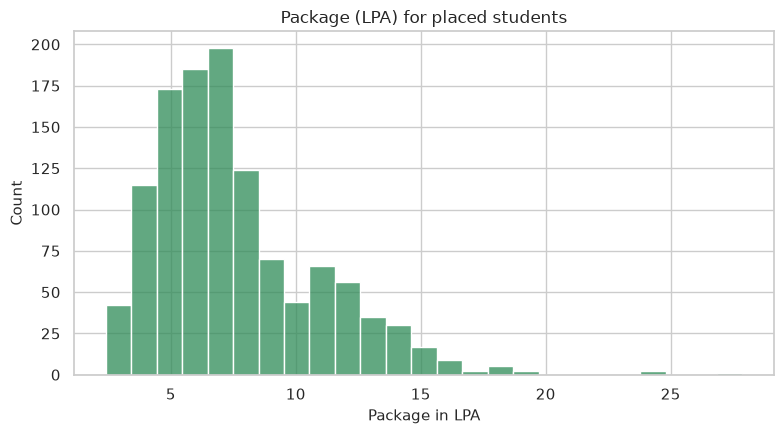

Median package (LPA): 6.87
Mean package (LPA):   7.57
Maximum package (LPA): 27.86

Notice: the maximum can be a rare 'dream offer'. Median is the fairer typical number.


In [18]:
# Packages of placed students only (LPA = lakhs per annum)
placed = df_clean[df_clean["is_placed"] == 1]

ax = sns.histplot(data=placed, x="package_lpa", bins=25, color="seagreen")
ax.set_title("Package (LPA) for placed students")
ax.set_xlabel("Package in LPA")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Median package (LPA):", placed["package_lpa"].median())
print("Mean package (LPA):  ", round(placed["package_lpa"].mean(), 2))
print("Maximum package (LPA):", placed["package_lpa"].max())
print()
print("Notice: the maximum can be a rare 'dream offer'. Median is the fairer typical number.")


**Pause.** From Stage 4 you should be able to say, in one line each:

- roughly what fraction of students got placed,
- which branches have more students in this file,
- whether CGPA is centred around 7,
- that a few packages are much higher than the rest (outliers).


---
# Stage 5 — Bivariate analysis (what relates to placement?)

Now we connect **student profile → outcome**. Each block answers one practical question.

We often plot **placement percentage** (a rate) rather than raw counts, so a small branch is comparable to a large branch.


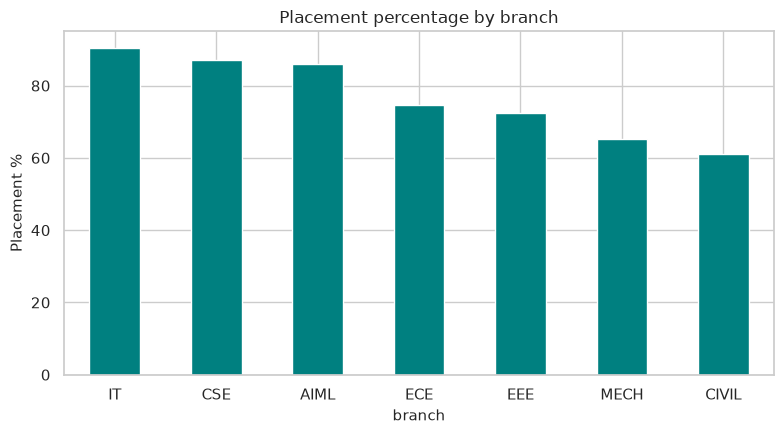

branch
IT       90.5
CSE      87.0
AIML     86.0
ECE      74.7
EEE      72.5
MECH     65.2
CIVIL    61.2
Name: is_placed, dtype: float64


In [19]:
def placement_percent(column):
    """Share of students placed, as a percentage, grouped by one column."""
    table = (
        df_clean.groupby(column, observed=True)["is_placed"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )
    return table.round(1)


def bar_percent(column, title, color="steelblue"):
    table = placement_percent(column)
    ax = table.plot(kind="bar", color=color)
    ax.set_title(title)
    ax.set_ylabel("Placement %")
    ax.set_xlabel(column)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print(table)


bar_percent("branch", "Placement percentage by branch", color="teal")


**How to read this:** a higher bar means a larger share of that branch got placed. CSE / AIML / IT usually sit above core branches in campus data like this. That is a market pattern, not a value judgement of the branch.


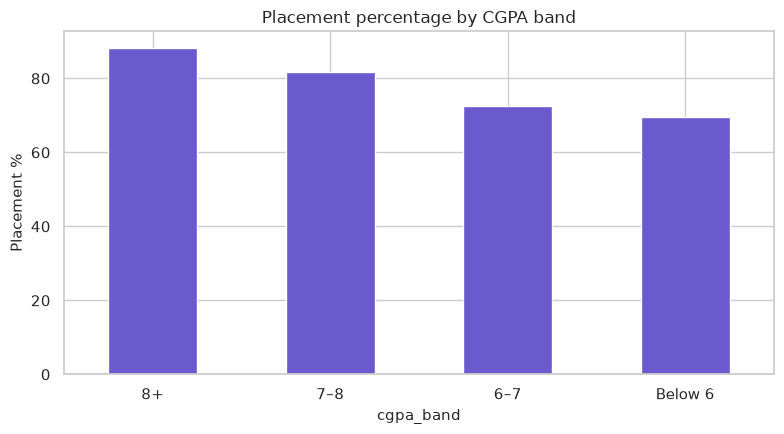

cgpa_band
8+         88.3
7–8        81.8
6–7        72.6
Below 6    69.6
Name: is_placed, dtype: float64


In [20]:
bar_percent("cgpa_band", "Placement percentage by CGPA band", color="slateblue")


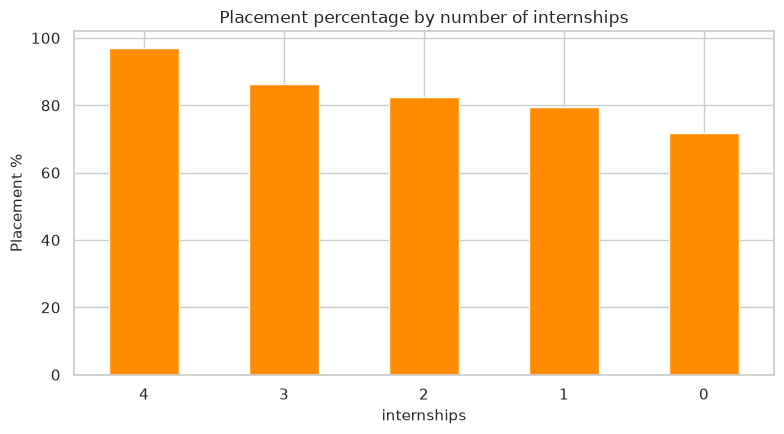

internships
4    97.1
3    86.3
2    82.5
1    79.5
0    71.9
Name: is_placed, dtype: float64


In [21]:
bar_percent("internships", "Placement percentage by number of internships", color="darkorange")


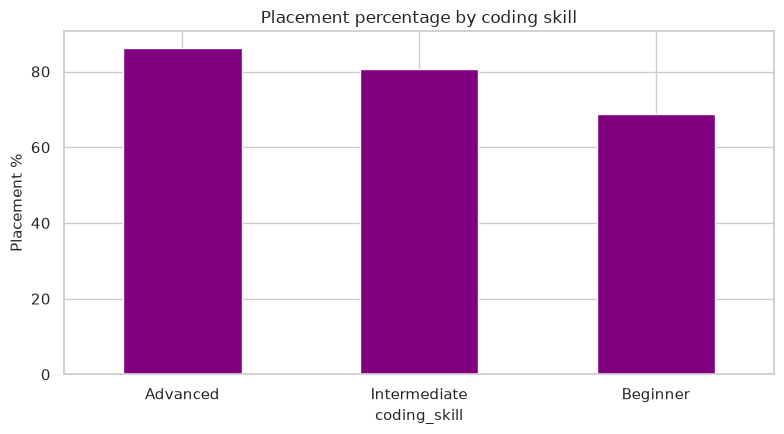

coding_skill
Advanced        86.3
Intermediate    80.7
Beginner        68.7
Name: is_placed, dtype: float64


In [22]:
bar_percent("coding_skill", "Placement percentage by coding skill", color="purple")


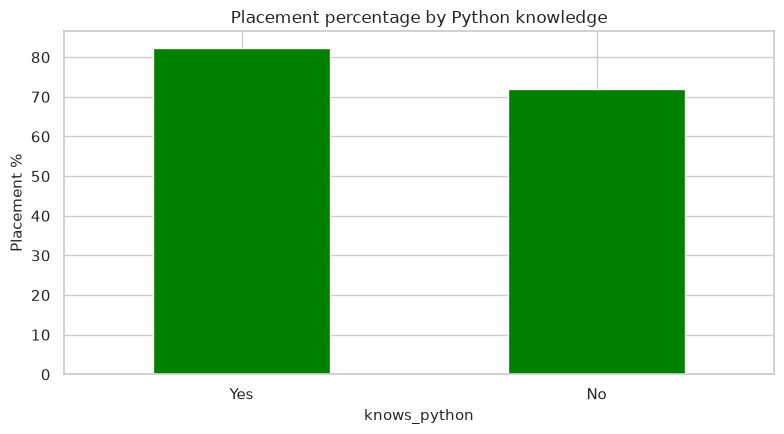

knows_python
Yes    82.4
No     72.0
Name: is_placed, dtype: float64

Python vs placement inside AIML / CSE only:
knows_python
No     81.8
Yes    87.5
Name: placement_%, dtype: float64


In [23]:
bar_percent("knows_python", "Placement percentage by Python knowledge", color="green")

print()
print("Python vs placement inside AIML / CSE only:")
tech = df_clean[df_clean["branch"].isin(["AIML", "CSE"])]
print(
    tech.groupby("knows_python")["is_placed"].mean().mul(100).round(1).rename("placement_%")
)


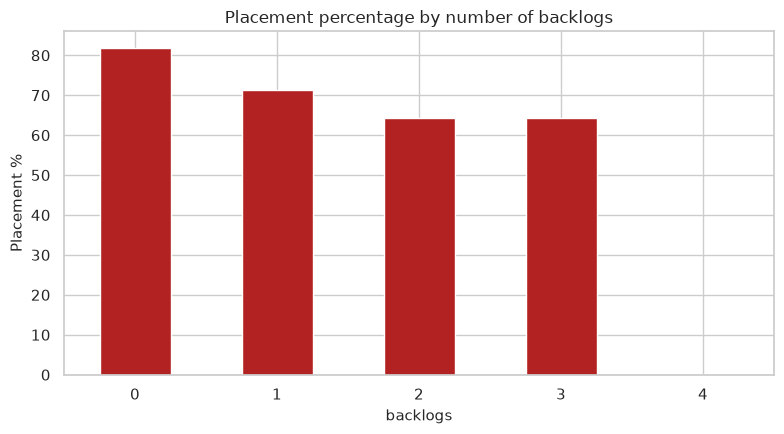

backlogs
0    81.9
1    71.4
2    64.3
3    64.3
4     0.0
Name: is_placed, dtype: float64

Communication skill:
communication_skill
Good         84.9
Excellent    79.4
Average      75.2
Poor         63.4
Name: is_placed, dtype: float64


In [24]:
bar_percent("backlogs", "Placement percentage by number of backlogs", color="firebrick")
print()
print("Communication skill:")
print(placement_percent("communication_skill"))


### Packages among those who *did* get placed

Placement is yes/no. Package is a second question: *among placed students, who got higher CTC?*


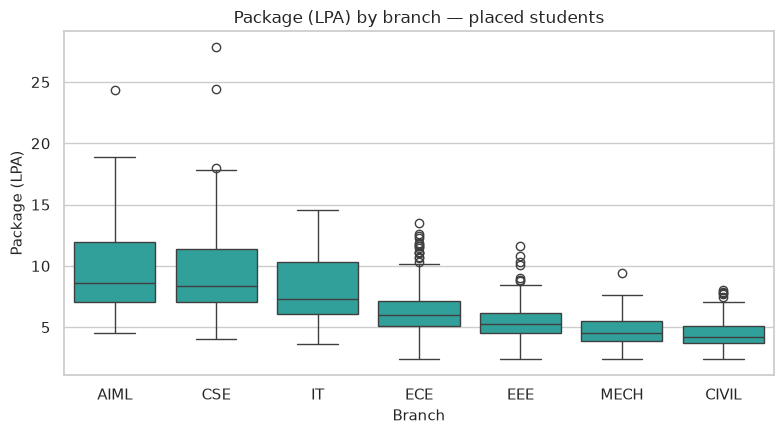

Median package (LPA) by branch:
branch
AIML     8.58
CSE      8.35
IT       7.28
ECE      6.02
EEE      5.26
MECH     4.56
CIVIL    4.22
Name: package_lpa, dtype: float64


In [25]:
placed = df_clean[df_clean["is_placed"] == 1]

order = (
    placed.groupby("branch")["package_lpa"].median().sort_values(ascending=False).index
)
ax = sns.boxplot(data=placed, x="branch", y="package_lpa", order=order, color="lightseagreen")
ax.set_title("Package (LPA) by branch — placed students")
ax.set_xlabel("Branch")
ax.set_ylabel("Package (LPA)")
plt.tight_layout()
plt.show()

print("Median package (LPA) by branch:")
print(placed.groupby("branch")["package_lpa"].median().sort_values(ascending=False).round(2))


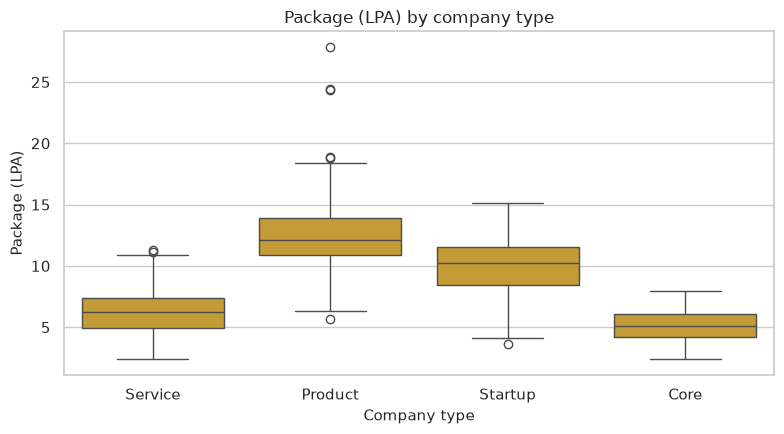

Median package (LPA) by company type:
company_type
Product    12.13
Startup    10.26
Service     6.28
Core        5.08
Name: package_lpa, dtype: float64

Common job roles for placed AIML students:
job_role
Data Analyst          64
ML Engineer           57
Software Developer    52
Data Scientist        27
QA Engineer            6
DevOps Engineer        3
Name: count, dtype: int64


In [26]:
placed = df_clean[df_clean["is_placed"] == 1]
# Exclude 'Not Applicable' if any slipped through
placed_co = placed[placed["company_type"] != "Not Applicable"]

ax = sns.boxplot(data=placed_co, x="company_type", y="package_lpa", color="goldenrod")
ax.set_title("Package (LPA) by company type")
ax.set_xlabel("Company type")
ax.set_ylabel("Package (LPA)")
plt.tight_layout()
plt.show()

print("Median package (LPA) by company type:")
print(placed_co.groupby("company_type")["package_lpa"].median().sort_values(ascending=False).round(2))
print()
print("Common job roles for placed AIML students:")
aiml_jobs = placed[placed["branch"] == "AIML"]["job_role"].value_counts()
print(aiml_jobs)


**Pause.** Write one sentence for each:

- internships,
- CGPA band,
- coding skill,
- backlogs.

Example: *“Students with 2 internships have a higher placement rate than students with 0 internships in this dataset.”*


---
# Stage 6 — Five-year trends and a bigger picture

Campus results are not only about one student. The **year** matters (for example the 2021 hiring slowdown). AIML as a branch also grew in the later years.


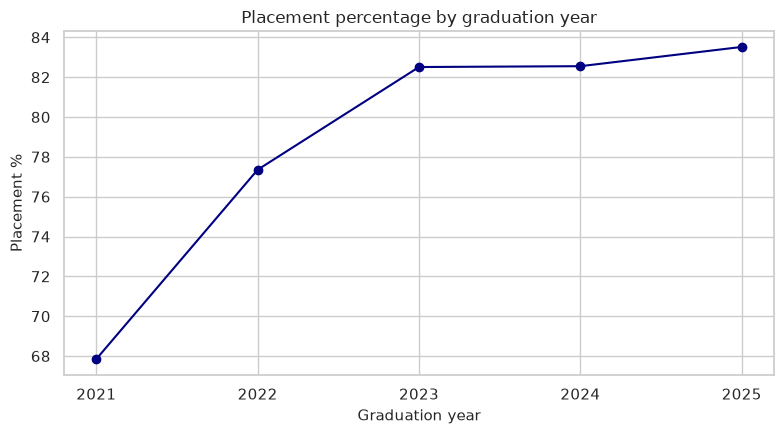

graduation_year
2021    67.8
2022    77.4
2023    82.5
2024    82.6
2025    83.5
Name: is_placed, dtype: float64


In [27]:
year_place = (
    df_clean.groupby("graduation_year")["is_placed"].mean().mul(100)
)

ax = year_place.plot(kind="line", marker="o", color="navy")
ax.set_title("Placement percentage by graduation year")
ax.set_xlabel("Graduation year")
ax.set_ylabel("Placement %")
ax.set_xticks(year_place.index)
plt.tight_layout()
plt.show()

print(year_place.round(1))


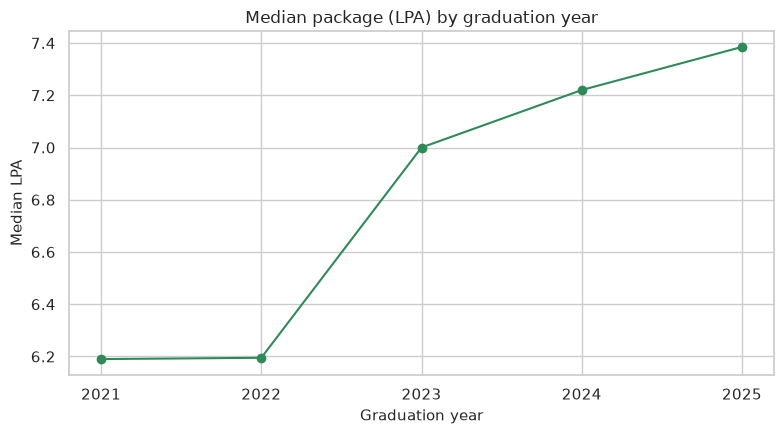

Median LPA by year:
graduation_year
2021    6.19
2022    6.20
2023    7.00
2024    7.22
2025    7.38
Name: package_lpa, dtype: float64

Median LPA by year for AIML vs MECH:
branch            AIML  MECH
graduation_year             
2021              7.28  4.17
2022              9.17  4.39
2023              8.32  4.50
2024              8.70  4.84
2025             11.69  5.69


In [28]:
placed = df_clean[df_clean["is_placed"] == 1]

year_pkg = placed.groupby("graduation_year")["package_lpa"].median()
ax = year_pkg.plot(kind="line", marker="o", color="seagreen")
ax.set_title("Median package (LPA) by graduation year")
ax.set_xlabel("Graduation year")
ax.set_ylabel("Median LPA")
ax.set_xticks(year_pkg.index)
plt.tight_layout()
plt.show()

print("Median LPA by year:")
print(year_pkg.round(2))
print()
print("Median LPA by year for AIML vs MECH:")
print(
    placed[placed["branch"].isin(["AIML", "MECH"])]
    .pivot_table(index="graduation_year", columns="branch", values="package_lpa", aggfunc="median")
    .round(2)
)


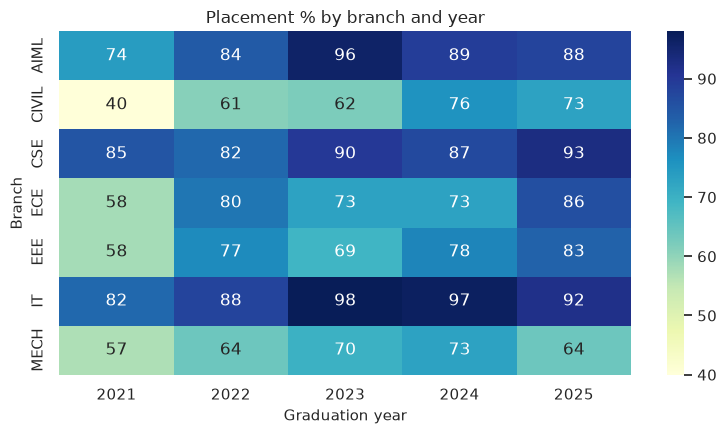

In [29]:
# Placement % for every branch in every year (heatmap)
rate = (
    df_clean.pivot_table(
        index="branch",
        columns="graduation_year",
        values="is_placed",
        aggfunc="mean",
    )
    * 100
)

ax = sns.heatmap(rate.round(0), annot=True, fmt=".0f", cmap="YlGnBu")
ax.set_title("Placement % by branch and year")
ax.set_xlabel("Graduation year")
ax.set_ylabel("Branch")
plt.tight_layout()
plt.show()


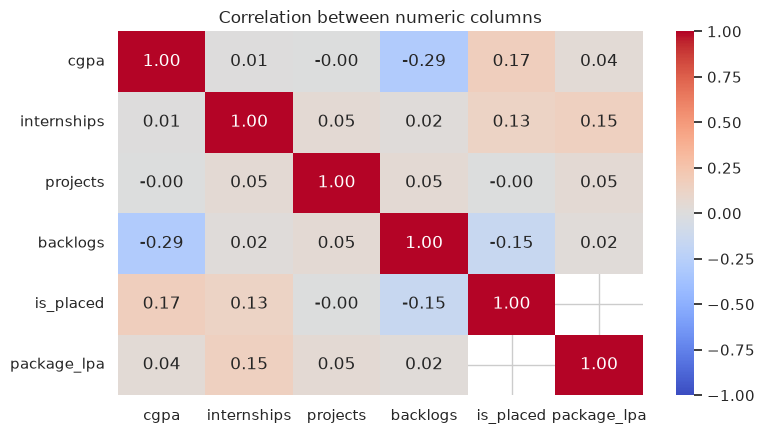

Read this as association, not proof of cause.
Example: internships may go with placement because stronger students also get internships.


In [30]:
# Correlation of numeric columns (–1 to +1)
# A number near +1 means two columns rise together.
num_cols = ["cgpa", "internships", "projects", "backlogs", "is_placed", "package_lpa"]
corr = df_clean[num_cols].corr()

ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Correlation between numeric columns")
plt.tight_layout()
plt.show()

print("Read this as association, not proof of cause.")
print("Example: internships may go with placement because stronger students also get internships.")


---
# Stage 7 — Insights and takeaways for a 2nd-year AIML student

Below we print a compact summary. Then we interpret it in words. Your numbers should match these tables.


In [31]:
print("=== Snapshot ===")
print("Students after cleaning:", len(df_clean))
print("Overall placement %:    ", round(df_clean["is_placed"].mean() * 100, 1))
print()
print("Placement % by branch")
print(placement_percent("branch"))
print()
print("Placement % by internships")
print(placement_percent("internships"))
print()
print("Placement % by CGPA band")
print(placement_percent("cgpa_band"))
print()
placed = df_clean[df_clean["is_placed"] == 1]
print("Median package (LPA) overall:", placed["package_lpa"].median())
print("Median package (LPA) AIML:   ", placed.loc[placed["branch"] == "AIML", "package_lpa"].median())


=== Snapshot ===
Students after cleaning: 1500
Overall placement %:     78.4

Placement % by branch
branch
IT       90.5
CSE      87.0
AIML     86.0
ECE      74.7
EEE      72.5
MECH     65.2
CIVIL    61.2
Name: is_placed, dtype: float64

Placement % by internships
internships
4    97.1
3    86.3
2    82.5
1    79.5
0    71.9
Name: is_placed, dtype: float64

Placement % by CGPA band
cgpa_band
8+         88.3
7–8        81.8
6–7        72.6
Below 6    69.6
Name: is_placed, dtype: float64

Median package (LPA) overall: 6.87
Median package (LPA) AIML:    8.58


## What the analysis is saying (in plain language)

Use this as a **template**. Adjust the wording if your printed numbers differ.

1. **Placement is not the same for every branch.** CSE, AIML, and IT typically show higher placement rates than CIVIL or MECH in this file. That reflects hiring demand, not “which branch is smarter”.
2. **Internships matter.** The placement rate usually rises as internships go from 0 to 2. For a 2nd-year student this is the most actionable chart in the notebook.
3. **CGPA helps, especially leaving the bottom band.** Moving from “Below 6” toward “7–8” is associated with a large jump. Perfect 9+ is not required for a first offer in this dataset.
4. **Coding skill and Python** move with better outcomes, particularly inside CSE / AIML. That matches what AIML interviews actually test.
5. **Backlogs hurt.** Even one backlog is associated with a lower placement rate here.
6. **Year matters.** 2021 is typically weaker (COVID hiring). Later years recover, and AIML packages trend up. Your effort still matters, but the market is a second factor.
7. **Do not worship the highest CTC.** A few dream offers pull the mean up. Quote the **median** package in a report.

## What this does *not* prove

- The file is educational / synthetic, not official SRM placement statistics.
- Charts show **association**. They do not prove “if I do an internship I will definitely be placed”.
- Many things are missing: interview performance, location, family support, luck.

## Practical motivation (what to do this year)

| Do this in 2nd year | Why the data points that way |
| --- | --- |
| Keep CGPA in a healthy band (aim 7+) | Lower bands have weaker placement rates |
| Plan at least one internship before final year | 0 internships is the weakest group |
| Treat Python as a default skill | Linked with placement in AIML / CSE |
| Build 2–3 projects you can explain | `projects` is in the file; interviews ask for them |
| Clear backlogs instead of carrying them | Negative association with placement |
| Practise speaking about your work | Communication skill is part of the table |

EDA does not replace hard work. It shows **where to aim** so 3rd-year and 4th-year effort is not random.


---
# Try it yourself

Run these extra questions and write two lines of answer under each. They use `df_clean` from Stage 3.


In [32]:
# Q1. Is there a gender gap in placement percentage?
print(placement_percent("gender"))

# Q2. Which college type has the highest placement %?
print()
print(placement_percent("college_type"))

# Q3. Among placed AIML students, what is the median package for Product vs Service companies?
aiml_placed = df_clean[(df_clean["branch"] == "AIML") & (df_clean["is_placed"] == 1)]
print()
print(aiml_placed.groupby("company_type")["package_lpa"].median().round(2))


gender
Female    78.4
Male      78.4
Name: is_placed, dtype: float64

college_type
NIT                            83.0
Deemed University              79.5
State University               77.3
Private Engineering College    76.1
Name: is_placed, dtype: float64

company_type
Product    14.16
Service     7.38
Startup    11.58
Name: package_lpa, dtype: float64


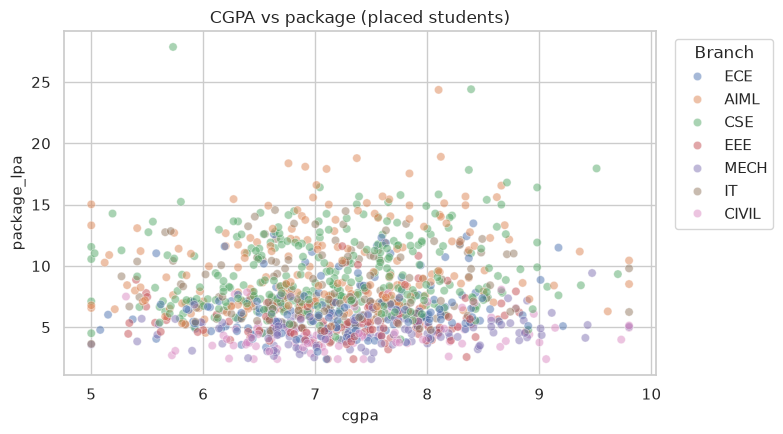

In [33]:
# Optional extra: scatter of CGPA vs package for placed students
placed = df_clean[df_clean["is_placed"] == 1]
ax = sns.scatterplot(data=placed, x="cgpa", y="package_lpa", hue="branch", alpha=0.5)
ax.set_title("CGPA vs package (placed students)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Branch")
plt.tight_layout()
plt.show()


## Next step (only after this notebook feels easy)

- Repeat the same stages on another CSV from `docs/PROJECT_IDEAS.md`.
- Do **not** jump to scikit-learn until you can explain every chart in Stage 5 in your own words.

You have now done a full beginner EDA loop: **import → inspect → clean → plot → interpret**.
